# SIMULATE ROOM IMPULSE RESPONSES (RIRs) & COMPARE WITH SCATTERING DELAY NETWORK (SDN)
─────────────────────────────────────────────────────────────────────────────
1. Generate RIRs via Image Source Model (ISM) + Ray Tracing (pyroomacoustics)
2. Visualize room setup and acoustic properties
3. Generate IRs from an untrained SDN baseline
4. Compare RIR vs SDN: early reflections, error metrics, T30

In [1]:
# IMPORTS
from collections import defaultdict
from io import BytesIO
from pathlib import Path

import imageio
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyroomacoustics as pra
import soundfile as sf
import torch
import yaml
from PIL import Image
from matplotlib.pyplot import tight_layout

# matplotlib.rcParams['figure.dpi'] = 100
# %matplotlib inline
mpl.rcParams.update({                       # LaTeX-like look (Computer Modern math, serif text)
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,
})
pra.random.seed(42)
# pra.constants.set("rir_hpf_fc", 250)
pra.constants.set("rir_hpf_enable", True)

# PROJECT SETUP

## UTILITY FUNCTIONS

In [2]:
def find_project_root(marker: str = '.git') -> Path:
    """Walk up from cwd until the project root marker is found."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(
        f'Project root not found: marker "{marker}" not found from {current}'
    )


def estimate_noise_variance(_rirs: np.ndarray, fs: int, noise_duration: float = 0.01) -> np.ndarray:
    """
    Estimate per-channel AWGN variance from the pre-onset silence window.

    Parameters
    ----------
    _rirs           : (n_mics, n_samples)
    fs             : sample rate [Hz]
    noise_duration : duration of pre-onset window [s]

    Returns
    -------
    sigma2 : (n_mics,) per-channel noise variance
    """
    n_noise = int(noise_duration * fs)
    assert 0 < n_noise < _rirs.shape[1], 'noise_duration too short or too long'
    return np.var(_rirs[:, :n_noise], axis=1)

def generate_mic_array(
    center: list[float],
    n_x: int,
    n_y: int,
    mic_spacing: float,
    save_path: Path,
    fs: int = 16_000,
) -> pra.MicrophoneArray:
    """
    Generate a planar rectangular microphone array and save positions to CSV.

    Uses pra.square_2D_array to generate a uniform 2D grid in the XY plane,
    then lifts it to 3D by appending a constant Z coordinate.

    Arguments:
        center      : (x, y, z) coordinates of the array center [m].
                      x, y define the center of the grid; z is the array plane height.
        n_x         : Number of microphones along the X axis.
        n_y         : Number of microphones along the Y axis.
        mic_spacing : Uniform spacing between adjacent microphones [m].
        save_path   : Path where the CSV of microphone positions is saved.
        fs          : Sampling frequency [Hz], required by pra.MicrophoneArray.

    Returns:
        pra.MicrophoneArray of shape (3, n_x * n_y), axis-aligned (phi=0).
    """
    cx, cy, z = center
    R_2d = pra.square_2D_array(center=[cx, cy], M=n_x, N=n_y, phi=0, d=mic_spacing)
    R = np.vstack([R_2d, np.full(n_x * n_y, z)])  # (3, n_x * n_y)

    mic_arr = pra.MicrophoneArray(R, fs=fs)

    pd.DataFrame(mic_arr.R.T, columns=['x', 'y', 'z']).to_csv(save_path, index=False)
    print(f'Array {n_x}×{n_y} | spacing {mic_spacing} m | {mic_arr.M} mics → "{save_path}"')
    return mic_arr


def build_room(
    room_dim,
    mat,
    source_pos,
    receiver_pos,
    fs: int = 16_000,
    max_order: int = 3,
    s2_awgn: float = 0.0,
    air_absorption: bool = True,
    ray_tracing: bool = True,
    use_rand_ism: bool = True,
    max_rand_disp: float = 0.05,
    receiver_radius: float = 0.1,
) -> pra.ShoeBox:
    """
    Build a pyroomacoustics ShoeBox room.
    RIR computation is deferred to allow visualization first.
    """
    r = pra.ShoeBox(
        room_dim,
        fs=fs,
        materials=mat,
        max_order=max_order,
        sigma2_awgn=s2_awgn,
        air_absorption=air_absorption,
        ray_tracing=ray_tracing,
        use_rand_ism=use_rand_ism,
        max_rand_disp=max_rand_disp,
    )
    if ray_tracing:
        r.set_ray_tracing(
            receiver_radius=receiver_radius,
        )
    r.add_source(source_pos)
    r.add_microphone(np.array(receiver_pos).T)
    return r


def compute_rirs(
    r: pra.ShoeBox, receiver_pos,
    fs: int = 16_000, output_path: str = 'generated_rirs.wav',
) -> np.ndarray:
    """
    Compute RIRs, trim fractional delay, and save as multichannel WAV.

    Returns
    -------
    np.ndarray  shape (n_mics, n_samples)
    """
    r.compute_rir()
    rir_list   = [r.rir[i][0] for i in range(len(receiver_pos))]
    rir_length = max(len(r) for r in rir_list)
    _rirs = np.zeros((len(receiver_pos), rir_length))
    for i, r in enumerate(rir_list):
        _rirs[i, :len(r)] = r

    global_delay = pra.constants.get('frac_delay_length') // 2
    print(f'Removing fractional-delay offset: {global_delay} samples')
    _rirs = np.ascontiguousarray(_rirs[:, global_delay:])

    if output_path:
        out = Path(output_path).resolve()
        out.parent.mkdir(parents=True, exist_ok=True)
        sf.write(out, _rirs.T.astype(np.float32), fs, subtype='FLOAT')
        print(f'Saved {len(receiver_pos)}-ch RIR → "{out}"')
    print(f'RIR shape: {_rirs.shape}  |  Duration: {_rirs.shape[1] / fs:.3f} s')
    return _rirs

## PROJECT ROOT

In [3]:
PROJECT_ROOT = find_project_root(marker='.git')
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/giorgiomagalini/PycharmProjects/differentiable-sdn


# DATASET SIMULATION

## Load Configuration

In [4]:
YAML_PATH = PROJECT_ROOT / 'config' / 'rooms' / 'simulated_room.yaml'
with open(YAML_PATH, 'r') as f:
    room_config = yaml.safe_load(f)

FS             = 16_000  # sample rate [Hz]

print('=' * 60)
print(f'Room dimensions : {room_config["room_dim"]} m')
print(f'Source position : {room_config["src_pos"]}')
print(f'Sample rate     : {FS} Hz')
print(f'Surfaces        : {list(room_config["materials"].keys())}')

Room dimensions : [4, 7, 3] m
Source position : [1.5, 1, 1.75]
Sample rate     : 16000 Hz
Surfaces        : ['floor', 'ceiling', 'north', 'south', 'east', 'west']


## Acoustic Analysis — Room Properties

In [5]:
def print_acoustic_summary(room_dim: list, room_materials: dict) -> None:
    """
    Print a preliminary acoustic summary of the room without instantiating it.

    Computes room geometry, broadband absorption, Sabine and Eyring T60 estimates,
    speed of sound from PRA global constants, and ISM parameters via pra.inverse_sabine.

    Arguments:
        room_dim       : Room dimensions [L, W, H] in meters.
        room_materials : Dict mapping surface names to (material_key, scattering_key) tuples,
                         as expected by pra.make_materials().
    """
    L, W, H = room_dim
    V = L * W * H
    areas = {
        'floor':   L * W, 'ceiling': L * W,
        'north':   L * H, 'south':   L * H,
        'east':    W * H, 'west':    W * H,
    }
    S_total = sum(areas.values())

    absorption_db = {
        mat_key: entry
        for category in pra.materials_data['absorption'].values()
        for mat_key, entry in category.items()
    }
    alpha_per_surface = {
        surface: np.mean(absorption_db[mat_key]['coeffs'])
        for surface, (mat_key, _) in room_materials.items()
    }
    total_absorption = sum(areas[s] * alpha_per_surface[s] for s in areas)
    mean_alpha = total_absorption / S_total

    t60_sabine = 0.161 * V / total_absorption
    t60_eyring = 0.161 * V / (-S_total * np.log(1 - total_absorption / S_total))

    c = pra.constants.get('c')
    e_absorption, max_order = pra.inverse_sabine(t60_sabine, room_dim)

    print(f'Speed of sound       : {c:.1f} m/s')
    print(f'Volume               : {V:.1f} m³')
    print(f'Total surface area   : {S_total:.1f} m²')
    print(f'Total absorption (A) : {total_absorption:.2f} m²')
    print(f'Mean alpha           : {mean_alpha:.4f}')
    print(f'Sabine T60           : {t60_sabine:.3f} s')
    print(f'Eyring T60           : {t60_eyring:.3f} s')
    print(f'ISM e_absorption     : {e_absorption:.4f}  (pra.inverse_sabine @ Sabine T60)')
    print(f'ISM max_order        : {max_order}')

print_acoustic_summary(room_config['room_dim'], room_config['materials'])

Speed of sound       : 343.0 m/s
Volume               : 84.0 m³
Total surface area   : 122.0 m²
Total absorption (A) : 43.74 m²
Mean alpha           : 0.3586
Sabine T60           : 0.309 s
Eyring T60           : 0.250 s
ISM e_absorption     : 0.3588  (pra.inverse_sabine @ Sabine T60)
ISM max_order        : 44


## Material Absorption Coefficients

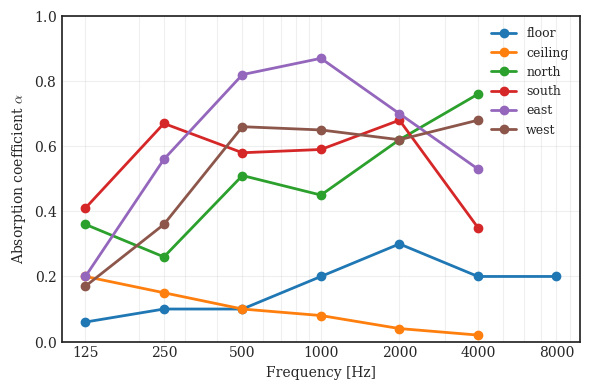

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [6]:
def plot_material_absorption(room_materials: dict) -> None:
    """Line plot of octave-band absorption coefficients, grouped by unique material."""
    absorption_db = {
        mat_key: entry
        for category in pra.materials_data['absorption'].values()
        for mat_key, entry in category.items()
    }
    center_freqs = pra.materials_data['center_freqs']

    surfaces_by_material = defaultdict(list)
    for surface, (mat_key, _) in room_materials.items():
        surfaces_by_material[mat_key].append(surface)

    fig, ax = plt.subplots(figsize=(6, 4))
    for mat_key, surfaces in surfaces_by_material.items():
        coeffs = absorption_db[mat_key]['coeffs']
        n      = min(len(center_freqs), len(coeffs))
        ax.plot(center_freqs[:n], coeffs[:n], marker='o', lw=2,
                  label=f'{", ".join(surfaces)}')

    ax.set_xscale('log')
    ax.set_xticks(center_freqs)
    ax.set_xticklabels(center_freqs)
    ax.set_xlabel(r'Frequency [Hz]')
    ax.set_ylabel(r'Absorption coefficient $\alpha$')
    # ax.set_title('Per-Material Absorption Coefficients', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
    fig.savefig(PROJECT_ROOT / 'figures' / 'room' / 'material_absorption.pdf', bbox_inches='tight')
    fig.savefig(PROJECT_ROOT / 'figures' / 'room' /'material_absorption.eps', bbox_inches='tight')


plot_material_absorption(room_config['materials'])

## Noise Variance Estimation

In [7]:
def load_sigma2_awgn(schiavoni_yaml: Path, project_root: Path) -> float:
    """
    Load real-room RIRs from schiavoni_room.yaml and estimate
    AWGN variance from the pre-onset silence window.

    Returns
    -------
    sigma2_awgn : mean noise variance averaged across sources and channels
    """
    with open(schiavoni_yaml, 'r') as yaml_file:
        cfg = yaml.safe_load(yaml_file)

    rirs_s1, fs1 = sf.read(project_root / cfg['rir']['path_s1'])
    rirs_s2, fs2 = sf.read(project_root / cfg['rir']['path_s2'])


    sigma2_s1 = estimate_noise_variance(rirs_s1.T, fs=fs1)
    sigma2_s2 = estimate_noise_variance(rirs_s2.T, fs=fs2)
    print(f'S1 — sigma2: mean={float(np.mean(sigma2_s1)):.2e}  std={float(np.std(sigma2_s1)):.2e}')
    print(f'S2 — sigma2: mean={float(np.mean(sigma2_s2)):.2e}  std={float(np.std(sigma2_s2)):.2e}')
    return float((sigma2_s1 + sigma2_s2).mean() / 2)


sigma2_awgn = load_sigma2_awgn(
    schiavoni_yaml=PROJECT_ROOT / 'config' / 'rooms' / 'schiavoni_room.yaml',
    project_root=PROJECT_ROOT
)
print(f'sigma2_awgn = {sigma2_awgn:.2e}')

S1 — sigma2: mean=6.46e-05  std=3.45e-05
S2 — sigma2: mean=6.09e-05  std=4.91e-05
sigma2_awgn = 6.28e-05


## Build Room (ISM + Ray Tracing)

In [8]:
materials = pra.make_materials(**{
    wall: tuple(props) for wall, props in room_config['materials'].items()
})

room = pra.ShoeBox(
    room_config['room_dim'],
    fs=FS,
    materials=materials,
    max_order=room_config['ism']['max_order'],
    sigma2_awgn=sigma2_awgn,
    air_absorption=room_config['environment']['air_absorption'],
    ray_tracing=room_config['ray_tracing']['enabled'],
    use_rand_ism=room_config['ism']['use_rand_ism'],
    max_rand_disp=room_config['ism']['max_rand_disp'],
)
if room_config['ray_tracing']['enabled']:
    room.set_ray_tracing(receiver_radius=room_config['ray_tracing']['receiver_radius'])

room.add_source(room_config['src_pos'])

mic_array = generate_mic_array(
    center=room_config['mic_pos'],
    n_x=room_config['mic_array_grid'][0],
    n_y=room_config['mic_array_grid'][1],
    mic_spacing=room_config['mic_spacing'],
    save_path=PROJECT_ROOT / room_config['mic_pos_path']
)
room.add_microphone(mic_array.R)

print(f'Room built: {room_config["room_dim"]} m | {mic_array.nmic} mics')

Array 8×8 | spacing 0.05 m | 64 mics → "/Users/giorgiomagalini/PycharmProjects/differentiable-sdn/data/simulated/pos_array.csv"
Room built: [4, 7, 3] m | 64 mics


## Room Visualization

/var/folders/b3/9p1vx9h57c39zzmtx2ds2ffw0000gn/T/ipykernel_4997/580189111.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


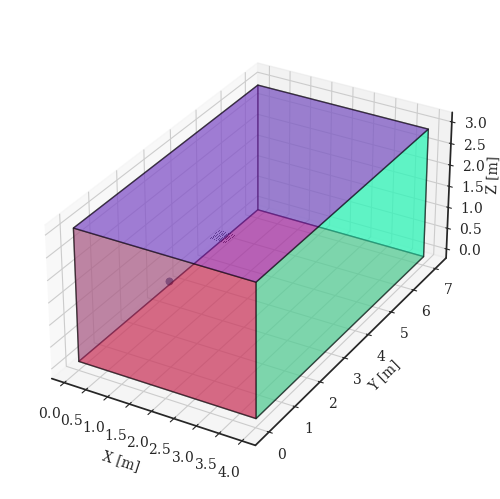

In [9]:
def room_visualization():
    fig, ax = room.plot(mic_marker_size=0.2)
    # ax.set_title('Simulated Room — pyroomacoustics view', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'X [m]')
    ax.set_ylabel(r'Y [m]')

    # 1. Aggiungi labelpad per allontanare l'etichetta dai tick
    ax.set_zlabel(r'Z [m]', labelpad=0.4)

    ax.set_box_aspect(room_config['room_dim'])

    # (Opzionale) Aiuta Matplotlib a ricalcolare gli spazi interni prima del salvataggio
    fig.tight_layout()

    # 2. Salva PRIMA di plt.show() e aggiungi pad_inches
    fig.savefig(f'{PROJECT_ROOT}/figures/room/room3D.eps', bbox_inches='tight')
    fig.savefig(f'{PROJECT_ROOT}/figures/room/room3D.pdf', bbox_inches='tight')

    # 3. Mostra il plot alla fine
    plt.show()

room_visualization()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


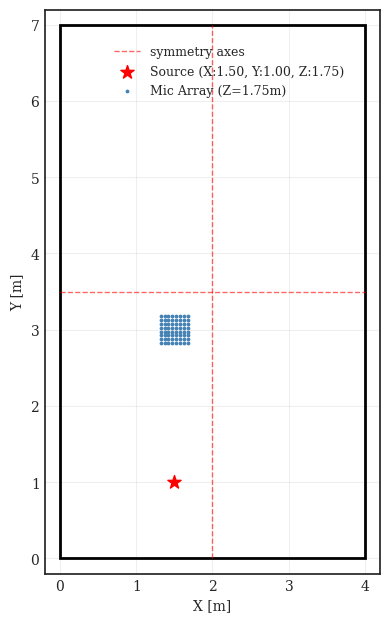

In [13]:
def plot_room_2d():
    L, W, _ = room_config['room_dim']
    src = room_config['src_pos']

    # Creazione array 2D
    array = pra.square_2D_array(
        center=room_config['mic_pos'][:-1],
        M=room_config['mic_array_grid'][0],
        N=room_config['mic_array_grid'][1],
        phi=0,
        d=room_config['mic_spacing']
    )

    # Inizializza la figura rispettando le proporzioni della stanza
    fig, ax = plt.subplots(figsize=(4, 4 * W / L))

    # Perimetro della stanza
    ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor='k', lw=2))

    # --- NUOVO: Assi di simmetria ---
    # Asse orizzontale (assegna la label solo qui)
    ax.plot([0, L], [W/2, W/2], color='red', linestyle='--', lw=1, alpha=0.6, label='symmetry axes')
    # Asse verticale (nessuna label per evitare duplicati in legenda)
    ax.plot([L/2, L/2], [0, W], color='red', linestyle='--', lw=1, alpha=0.6)

    # Plot della Sorgente
    ax.scatter(src[0], src[1], c='red', s=100, marker='*', zorder=5,
               label=rf'Source (X:{src[0]:.2f}, Y:{src[1]:.2f}, Z:{src[2]:.2f})')

    # Plot dei Microfoni (Tutti in un singolo comando!)
    # array[0, :] prende tutte le X, array[1, :] prende tutte le Y
    ax.scatter(array[0, :], array[1, :], c='steelblue', s=3, marker='o', zorder=5,
               label=rf'Mic Array (Z={room_config["mic_pos"][2]:.2f}m)')

    # Formattazione assi
    ax.set_xlim(-0.2, L + 0.2)
    ax.set_ylim(-0.2, W + 0.2)
    ax.set_aspect('equal')
    ax.set_xlabel(r'X [m]')
    ax.set_ylabel(r'Y [m]')

    # Legenda ora pulita (solo 2 voci)
    ax.legend(fontsize=9, loc='upper right', borderaxespad=2.5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Salvataggio
    fig.savefig(f'{PROJECT_ROOT}/figures/room/room2D.eps', bbox_inches='tight')
    fig.savefig(f'{PROJECT_ROOT}/figures/room/room2D.pdf', bbox_inches='tight')
    plt.show()

plot_room_2d()

## Compute RIRs

In [11]:
def plot_octave_band_rt(rir: np.ndarray, fs: int, base_frequency: float = 125.0) -> dict:
    """
    Measure T20, T30, T60 per octave band using AntoniOctaveFilterBank.

    Arguments:
        rir            : (n_samples,) impulse response.
        fs             : Sampling frequency [Hz].
        base_frequency : Center frequency of the first octave band [Hz].

    Returns:
        dict with keys 'freqs', 'T20', 'T30', 'T60' — lists of floats, one per band.
    """
    fb = pra.acoustics.AntoniOctaveFilterBank(base_frequency=base_frequency, fs=fs, n_fft=512)
    rir_bands    = fb.analysis(rir, oversampling=2)  # (n_samples, n_bands)
    center_freqs = fb.centers

    results = {'freqs': [int(freq) for freq in center_freqs], 'T20': [], 'T30': [], 'T60': []}
    for i in range(len(center_freqs)):
        band_signal = rir_bands[:, i]
        for decay_db, label in [(20, 'T20'), (30, 'T30'), (60, 'T60')]:
            try:
                results[label].append(pra.experimental.measure_rt60(band_signal, fs=fs, decay_db=decay_db))
            except Exception:
                results[label].append(int('nan'))
    return results


def compute_rts(_rirs: np.ndarray, fs: int, base_frequency: float = 125.0) -> list[dict]:
    """
    Compute T20/T30/T60 per octave band for every microphone.

    Arguments:
        _rirs           : (n_mics, n_samples) RIR array.
        fs             : Sampling frequency [Hz].
        base_frequency : Center frequency of the first octave band [Hz].

    Returns:
        List of n_mics dicts, each with keys 'freqs', 'T20', 'T30', 'T60'.
    """
    return [plot_octave_band_rt(_rirs[i], fs=fs, base_frequency=base_frequency)
            for i in range(_rirs.shape[0])]


def _plot_rt_summary(_rts: list[dict], verbose: bool = False) -> None:
    """
    Print and/or plot a statistical summary of T20/T30/T60 across microphones.

    Shows mean ± 1σ shaded ribbon per metric — standard representation in room
    acoustics literature (e.g. ISO 3382).

    Arguments:
        _rts     : List of per-mic RT dicts as returned by compute_rts().
        verbose : If True, also print mean and std per band and metric.
    """
    freqs  = _rts[0]['freqs']
    styles = {
        'T20': ('steelblue',  '--'),
        'T30': ('darkorange', '-'),
        'T60': ('firebrick',  ':'),
    }

    if verbose:
        header = f"{'Freq [Hz]':>10}"
        for label in ('T20', 'T30', 'T60'):
            header += f"  {label + ' mean':>10}  {label + ' std':>8}"
        print(header)
        for j, freq in enumerate(freqs):
            row = f'{freq:>10}'
            for label in ('T20', 'T30', 'T60'):
                vals = [rt[label][j] for rt in _rts]
                row += f'  {np.nanmean(vals):>10.3f}  {np.nanstd(vals):>8.3f}'
            print(row)

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, (color, ls) in styles.items():
        # (n_mics, n_bands)
        data = np.array([[rt[label][j] for j in range(len(freqs))] for rt in _rts])
        mean = np.nanmean(data, axis=0)
        std  = np.nanstd(data, axis=0)
        ax.semilogx(freqs, mean, color=color, ls=ls, lw=2, marker='o', ms=5, label=label)
        ax.fill_between(freqs, mean - std, mean + std, color=color, alpha=0.2)

    ax.set_xticks(freqs)
    ax.set_xticklabels([str(freq) for freq in freqs])
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Reverberation time [s]')
    ax.set_title(
        f'T20 / T30 / T60 per Octave Band  —  mean ± 1σ across {len(_rts)} mics',
        fontsize=12, fontweight='bold',
    )
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

import sys
sys.path.insert(0, str(PROJECT_ROOT))
from calibration import rescale_rirs_to_unit_excitation

def postprocess_rirs(
    r: pra.ShoeBox,
    fs: int,
    clip_factor: float = 1.1,
    base_frequency: float = 125.0,
    plot_rt: bool = False,
    rescale: bool = False,
    receiver_positions: np.ndarray | None = None,
    src_pos: np.ndarray | None = None,
    device: torch.device | None = None,
) -> tuple[np.ndarray, list[dict]]:
    """
    Post-process RIRs from a simulated room: stack, trim fractional delay,
    compute RTs, clip to a multiple of RT max, and optionally rescale to unit excitation.

    Arguments:
        r               : PRA ShoeBox on which compute_rir() has already been called.
        fs                 : Sampling frequency [Hz].
        clip_factor        : RIRs are clipped to clip_factor * T_max seconds (default 1.1).
        base_frequency     : First octave band center frequency for RT estimation [Hz].
        plot_rt            : If True, print and plot T20/T30/T60 mean ± 1σ across mics.
        rescale            : If True, rescale to unit excitation. Requires receiver_positions,
                             src_pos, and device.
        receiver_positions : Mic positions array of shape (n_mics, 3). Required if rescale=True.
        src_pos            : Source position array of shape (3,). Required if rescale=True.
        device             : Torch device for rescaling. Defaults to CUDA if available.

    Returns:
        Tuple of:
            np.ndarray of shape (n_mics, n_samples).
            list of per-mic RT dicts with keys 'freqs', 'T20', 'T30', 'T60'.
    """
    n_mics = len(r.rir)
    rir_list   = [r.rir[i][0] for i in range(n_mics)]
    rir_length = max(len(r) for r in rir_list)

    _rirs = np.zeros((n_mics, rir_length))
    for i, r in enumerate(rir_list):
        _rirs[i, :len(r)] = r

    global_delay = pra.constants.get('frac_delay_length') // 2
    _rirs = np.ascontiguousarray(_rirs[:, global_delay:])
    print(f'Fractional-delay offset removed : {global_delay} samples')

    _rts = compute_rts(_rirs, fs=fs, base_frequency=base_frequency)

    _max_rt = max(
        max(v for rt in _rts for v in rt[label])
        for label in ('T20', 'T30', 'T60')
    )
    clip_samples = int(_max_rt * clip_factor * fs)
    _rirs = _rirs[:, :clip_samples]
    print(f'RT max                          : {_max_rt:.3f} s')
    print(f'Clipped to                      : {clip_samples} samples  |  {clip_samples / fs:.3f} s  ({clip_factor * 100:.0f}% of T_max)')

    if plot_rt:
        _plot_rt_summary(_rts, verbose=True)

    if rescale:
        if receiver_positions is None or src_pos is None:
            raise ValueError('receiver_positions and src_pos are required when rescale=True.')
        if device is None:
            device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        factory_kwargs = {'device': device, 'dtype': torch.float32}
        _rirs = rescale_rirs_to_unit_excitation(
            torch.tensor(_rirs, **factory_kwargs).unsqueeze(0),
            torch.tensor(receiver_positions, **factory_kwargs),
            torch.tensor(src_pos, **factory_kwargs).unsqueeze(0),
        ).squeeze(0).cpu().numpy()
        print('Rescaled to unit excitation')

    print(f'RIR shape                       : {_rirs.shape}  |  {_rirs.shape[1] / fs:.3f} s')
    return _rirs, _rts


def load_rirs(
    path: Path,
    fs: int,
    base_frequency: float = 125.0,
    plot_rt: bool = False,
) -> tuple[np.ndarray, list[dict]]:
    """
    Load a multichannel RIR WAV file and compute RT estimates.

    Arguments:
        path           : Path to the WAV file.
        fs             : Sampling frequency [Hz].
        base_frequency : First octave band center frequency for RT estimation [Hz].
        plot_rt        : If True, print and plot T20/T30/T60 mean ± 1σ across mics.

    Returns:
        Tuple of:
            np.ndarray of shape (n_mics, n_samples).
            list of per-mic RT dicts with keys 'freqs', 'T20', 'T30', 'T60'.
    """
    _rirs, _ = sf.read(Path(path).resolve(), always_2d=True)
    _rirs = _rirs.T  # (n_samples, n_mics) → (n_mics, n_samples)
    print(f'Loaded {_rirs.shape[0]}-ch RIR from "{path}"  |  shape {_rirs.shape}  |  {_rirs.shape[1] / fs:.3f} s')

    _rts = compute_rts(_rirs, fs=fs, base_frequency=base_frequency)

    if plot_rt:
        _plot_rt_summary(_rts, verbose=True)

    return _rirs, _rts


def save_rirs(_rirs: np.ndarray, fs: int, output_path: Path) -> None:
    """
    Save a multichannel RIR array to a 32-bit float WAV file.

    Arguments:
        _rirs        : RIR array of shape (n_mics, n_samples).
        fs          : Sampling frequency [Hz].
        output_path : Destination path for the WAV file.
    """
    output_path = Path(output_path).resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(output_path, _rirs.T.astype(np.float32), fs, subtype='FLOAT')
    print(f'Saved {_rirs.shape[0]}-ch RIR → "{output_path}"')


In [12]:
rir_path = PROJECT_ROOT / room_config['rir_path']

if rir_path.exists():
    answer = input(f'RIRs found at "{rir_path}". Load? [y/n]: ').strip().lower()
    if answer == 'y':
        rirs, rts = load_rirs(path=rir_path, fs=FS, plot_rt=True)
    else:
        room.compute_rir()
        rirs, rts = postprocess_rirs(
            r=room,
            fs=FS,
            clip_factor=1.1,
            plot_rt=True,
            rescale=True,
            receiver_positions=mic_array.R.T,
            src_pos=room_config['src_pos'])
        save_rirs(_rirs=rirs, fs=FS, output_path=rir_path)
else:
    print(f'No RIRs found at "{rir_path}". Computing...')
    room.compute_rir()
    rirs, rts = postprocess_rirs(
        r=room,
        fs=FS,
        clip_factor=1.1,
        plot_rt=True,
        rescale=True,
        receiver_positions=mic_array.R.T,
        src_pos=room_config['src_pos'])
    save_rirs(_rirs=rirs, fs=FS, output_path=rir_path)

KeyboardInterrupt: Interrupted by user

# SDN BASELINE ANALYSIS (UNTRAINED)

## SDN Absorption Coefficient Initialization

In [ ]:
max_rt = max(
    max(v for rt in rts for v in rt[label])
    for label in ('T20', 'T30', 'T60')
)
print(f'Absolute RT max: {max_rt:.3f} s')

mean_rt = float(np.mean([
    np.mean([rt['T20'] for rt in rts]),
    np.mean([rt['T30'] for rt in rts]),
    np.mean([rt['T60'] for rt in rts]),
]))
print(f'Mean RT (avg of T20/T30/T60): {mean_rt:.3f} s')
alpha_sdn,_ = pra.inverse_sabine(mean_rt, room_config['room_dim'])
print(alpha_sdn)

## Generate SDN Impulse Responses

In [ ]:
def run_sdn_inference(
    room_conf: dict,
    sdn_conf: dict,
    _rirs: np.ndarray,
    receiver_pos: list,
    alpha: float,
    fs: int,
) -> np.ndarray:
    device         = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    factory_kwargs = {'device': device, 'dtype': torch.float32}

    sdn = SDN(
        room_dim      = room_conf['room_dim'],
        N             = sdn_conf['sdn']['N'],
        sr            = sdn_conf['sr'],
        c             = sdn_conf['c'],
        junction_type = sdn_conf['sdn']['junction_type'],
        fir_order     = sdn_conf['sdn']['fir_order'],
        alpha         = alpha,
        **factory_kwargs,
    )
    print(f'Device: {device.type} | alpha={alpha:.4f} | N={sdn_conf["sdn"]["N"]}')

    x_ir           = torch.zeros(_rirs.shape[-1], **factory_kwargs)
    x_ir[0]        = 1.0
    mic_pos_tensor = torch.tensor(receiver_pos, **factory_kwargs)
    src_pos_tensor = torch.tensor(room_conf['src_pos'], **factory_kwargs)

    with torch.no_grad():
        irs = sdn(x_ir, src_pos_tensor, mic_pos_tensor)

    _irs_np = irs.cpu().numpy()
    print(f'IR shape: {_irs_np.shape}  |  Duration: {_irs_np.shape[1] / fs:.3f} s')
    return _irs_np

import sys
sys.path.insert(0, str(PROJECT_ROOT))
from sdn import SDN

sdn_config_path = PROJECT_ROOT / 'config' / 'simulated' / 'sdn_householder_mlp_full_16_32.yaml'
with open(sdn_config_path, 'r') as f:
    sdn_config = yaml.safe_load(f)

irs_np = run_sdn_inference(
    room_config,
    sdn_config,
    rirs,
    mic_array.R.T,
    alpha_sdn,
    FS)

## Animated GIF — Early Reflections

In [ ]:
def generate_comparison_gif(
    _rirs: np.ndarray, _irs_np: np.ndarray, receiver_pos: list,
    fs: int, output_dir: Path, early_s: float = 0.02, start_s: float = 0.0,  n_grid: int = 5,
) -> None:
    """Save an animated GIF comparing RIR vs SDN early reflections."""

    start_samples = int(start_s * fs)
    early_samples = int(early_s * fs)

    output_dir.mkdir(parents=True, exist_ok=True)
    t_early      = np.arange(start_samples, early_samples) / fs
    total_mics   = len(receiver_pos)
    step         = max(1, total_mics // (n_grid * n_grid))
    grid_indices = [i * step for i in range(n_grid * n_grid) if i * step < total_mics]

    slice_rirs = _rirs[grid_indices, start_samples:early_samples]
    slice_sdn  = _irs_np[grid_indices, start_samples:early_samples]
    y_min, y_max = float(min(slice_rirs.min(), slice_sdn.min())), float(max(slice_rirs.max(), slice_sdn.max()))
    margin  = (y_max - y_min) * 0.1
    y_limit = y_min - margin, y_max + margin

    frames = []
    for mic_idx in grid_indices:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(t_early, _rirs[mic_idx, start_samples:early_samples],
                'b-', lw=2.5, label='RIR (pra)', alpha=0.8)
        ax.plot(t_early, _irs_np[mic_idx, start_samples:early_samples],
                'r--', lw=2.5, label='IR (SDN)', alpha=0.8)
        ax.fill_between(t_early,
                        _rirs[mic_idx, start_samples:early_samples],
                        _irs_np[mic_idx, start_samples:early_samples],
                        alpha=0.2, color='gray', label='Difference')
        pos = receiver_pos[mic_idx]
        ax.set_ylim(y_limit)
        ax.set_xlabel('Time [s]', fontsize=12)
        ax.set_ylabel('Amplitude', fontsize=12)
        ax.set_title(
            f'Early Reflections: Mic {mic_idx}\n'
            f'Pos: ({pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f})',
            fontsize=13, fontweight='bold',
        )
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        buf = BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        frames.append(np.array(Image.open(buf)))
        plt.close(fig)

    gif_path = output_dir / 'rir_vs_sdn_early_reflections.gif'
    imageio.mimsave(gif_path, frames, duration=0.5, loop=0)
    print(f'GIF saved → "{gif_path}"  ({len(frames)} frames)')


generate_comparison_gif(
    rirs, irs_np, mic_array.R.T, FS,
    output_dir=PROJECT_ROOT / 'figures' / 'sdn_vs_rir_comparison',
)

## Error Metrics — RIR vs SDN

In [ ]:
def plot_error_metrics(
    _rirs: np.ndarray, _irs_np: np.ndarray, n_x: int, n_y: int
) -> None:
    """Print dE% statistics and plot spatial heatmaps."""
    dE    = np.abs(np.sum(_rirs ** 2, axis=1) - np.sum(_irs_np ** 2, axis=1)) \
            / (np.sum(_rirs ** 2, axis=1) + 1e-12)

    for name, values in [('dE%', dE * 100)]:
        print(f'{name:4s} — mean: {float(np.mean(values)):.2f}%  '
              f'std: {float(np.std(values)):.2f}%  '
              f'min: {float(np.min(values)):.2f}%  '
              f'max: {float(np.max(values)):.2f}%')

    grid_shape = (n_y, n_x)
    fig, ax  = plt.subplots(figsize=(16, 4))
    im = ax.imshow(dE.reshape(grid_shape), cmap='viridis')
    ax.set_title('Energy Difference (ratio)', fontsize=12, fontweight='bold')
    ax.set_xlabel('X [mic]')
    ax.set_ylabel('Y [mic]')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_error_metrics(rirs, irs_np, room_config['mic_array_grid'][0], room_config['mic_array_grid'][1])

## T30 Comparison — RIR vs SDN

In [ ]:
def plot_t30_comparison(_rirs: np.ndarray, _irs_np: np.ndarray, fs: int) -> None:
    """Plot per-channel T30 for RIR and SDN and print error statistics."""
    t30_rir = np.array([pra.experimental.measure_rt60(_rirs[i], fs=fs, decay_db=30)
                        for i in range(_rirs.shape[0])])
    t30_sdn = np.array([pra.experimental.measure_rt60(_irs_np[i], fs=fs, decay_db=30)
                        for i in range(_irs_np.shape[0])])

    mask      = ~np.isnan(t30_rir) & ~np.isnan(t30_sdn)
    clean_rir = t30_rir[mask]
    clean_sdn = t30_sdn[mask]

    plt.figure(figsize=(12, 6))
    plt.plot(t30_rir, 'bo', label='T30 PRA', alpha=0.6)
    plt.plot(t30_sdn, 'rx', label='T30 SDN', alpha=0.6)
    plt.fill_between(range(len(t30_rir)), t30_rir, t30_sdn, color='gray', alpha=0.1)
    plt.axhline(float(np.mean(clean_rir)), color='blue', ls='--',
                label=f'Mean PRA: {float(np.mean(clean_rir)):.3f} s')
    plt.axhline(float(np.mean(clean_sdn)), color='red',  ls='--',
                label=f'Mean SDN: {float(np.mean(clean_sdn)):.3f} s')
    plt.xlabel('Microphone channel')
    plt.ylabel('T30 [s]')
    plt.title('T30 Comparison: RIR vs SDN', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Valid channels   : {mask.sum()}/{len(t30_rir)}')
    print(f'Mean |T30 error| : {float(np.mean(np.abs(clean_rir - clean_sdn)) * 1000):.2f} ms')


plot_t30_comparison(rirs, irs_np, FS)

## Acoustic Curve GIFs — RIR vs Untrained SDN

In [ ]:
from curves import energy_decay_curve, mel_energy_decay_relief, echo_density_profile
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

GIF_DIR = PROJECT_ROOT / 'figures' / 'gifs' / 'sdn_baseline'
GIF_DIR.mkdir(parents=True, exist_ok=True)

GIF_INTERVAL = 120  # ms per frame
HOP_LENGTH   = 160  # samples (for EDR extent computation)

n_mics_total = rirs.shape[0]
mic_indices  = [0, n_mics_total // 2, n_mics_total - 1]
mic_labels   = [f"Mic {i}" for i in mic_indices]

# Convert to (T, n_mics) float32 tensors — same convention as analysis notebook
rirs_t   = torch.tensor(rirs.T,    dtype=torch.float64)   # (T, n_mics)
irs_np_t = torch.tensor(irs_np.T,  dtype=torch.float64)   # (T, n_mics)

# rirs_t   = rirs_t   / rirs_t.norm(dim=0, keepdim=True)    # norma per colonna (per mic)
# irs_np_t = irs_np_t / irs_np_t.norm(dim=0, keepdim=True)

# Synchronize lengths
min_len   = min(rirs_t.shape[0], irs_np_t.shape[0])
rirs_sync = rirs_t[:min_len]    # (T, n_mics)
irs_sync  = irs_np_t[:min_len]  # (T, n_mics)

def _save_gif(anim: animation.FuncAnimation, name: str) -> None:
    path = GIF_DIR / name
    anim.save(path, writer='pillow', fps=1000 // GIF_INTERVAL)
    print(f"Saved: {path}")

In [ ]:
def plot_edc(
    _rirs: torch.Tensor,
    irs: torch.Tensor,
    fs: int,
    _mic_indices: list[int],
    _mic_labels: list[str],
    gif_interval: int = 100,
    zoom_xlim: tuple[float, float] = (0.0, 0.02),
    zoom_ylim: tuple[float, float] = (-10, 5),
    save_gif_fn = None,
) -> None:
    """
    Plot Schroeder EDC for RIR vs SDN: static (3 mics) and animated GIF (all mics).

    Arguments:
        _rirs         : (n_samples, n_mics) RIR tensor.
        irs          : (n_samples, n_mics) SDN IR tensor.
        fs           : Sampling frequency [Hz].
        _mic_indices  : Indices of the 3 mics for the static plot.
        _mic_labels   : Display labels for the 3 mics.
        gif_interval : Frame interval for the GIF animation [ms].
        zoom_xlim    : Time axis limits for the inset zoom.
        zoom_ylim    : dB axis limits for the inset zoom.
        save_gif_fn  : Optional callable(anim, filename) to save the GIF.
    """
    _n_mics_total = _rirs.shape[1]

    # ── static ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, mic_idx, mic_label in zip(axes, _mic_indices, _mic_labels):
        edc_rir = energy_decay_curve(_rirs[:, mic_idx], return_db=True)
        edc_sdn = energy_decay_curve(irs[:, mic_idx],  return_db=True)
        t = torch.arange(len(edc_rir)) / fs

        ax.plot(t, edc_rir, label='RIR (pra)',       linewidth=1.5, alpha=0.8)
        ax.plot(t, edc_sdn, label='SDN (untrained)', linewidth=1.5, alpha=0.8, linestyle='--')
        ax.set_title(mic_label)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Schroeder EDC (dB)')
        ax.set_ylim(-120, 15)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        axins = inset_axes(ax, width='40%', height='40%', loc='lower left')
        axins.plot(t, edc_rir, linewidth=1.0, alpha=0.8)
        axins.plot(t, edc_sdn, linewidth=1.0, alpha=0.8, linestyle='--')
        axins.set_xlim(*zoom_xlim)
        axins.set_ylim(*zoom_ylim)
        axins.grid(True, alpha=0.3)
        plt.setp(axins.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        plt.setp(axins.get_yticklabels(), fontsize=6)
        mark_inset(ax, axins, loc1=1, loc2=2, fc='none', ec='0.5', lw=0.8)

    plt.suptitle('EDC — RIR vs Untrained SDN (3 mics)', fontsize=13, fontweight='bold')
    plt.subplots_adjust(left=0.1, right=0.95, top=0.88, bottom=0.2)
    plt.show()

    # ── GIF ───────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    line_rir, = ax.plot([], [], label='RIR (pra)',       linewidth=1.5, alpha=0.9)
    line_sdn, = ax.plot([], [], label='SDN (untrained)', linewidth=1.5, alpha=0.9, linestyle='--')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Schroeder EDC (dB)')
    ax.set_ylim(-120, 15)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    title = ax.set_title('')

    axins = inset_axes(ax, width='40%', height='40%', loc='lower left')
    ins_rir, = axins.plot([], [], linewidth=1.0, alpha=0.8)
    ins_sdn, = axins.plot([], [], linewidth=1.0, alpha=0.8, linestyle='--')
    axins.set_xlim(*zoom_xlim)
    axins.set_ylim(*zoom_ylim)
    axins.grid(True, alpha=0.3)
    plt.setp(axins.get_xticklabels(), rotation=45, ha='right', fontsize=6)
    plt.setp(axins.get_yticklabels(), fontsize=6)
    mark_inset(ax, axins, loc1=1, loc2=2, fc='none', ec='0.5', lw=0.8)

    def _frame(_mic_idx):
        _edc_rir = energy_decay_curve(_rirs[:, _mic_idx], return_db=True).numpy()
        _edc_sdn = energy_decay_curve(irs[:, _mic_idx],  return_db=True).numpy()
        _t = np.arange(len(_edc_rir)) / fs
        line_rir.set_data(_t, _edc_rir);  line_sdn.set_data(t, _edc_sdn)
        ins_rir.set_data(_t, _edc_rir);   ins_sdn.set_data(t, _edc_sdn)
        ax.set_xlim(0, float(_t[-1]))
        title.set_text(f'EDC — Mic {_mic_idx} / {_n_mics_total - 1}  |  RIR vs Untrained SDN')
        return line_rir, line_sdn, ins_rir, ins_sdn, title

    anim = FuncAnimation(fig, _frame, frames=_n_mics_total, interval=gif_interval, blit=True)
    plt.subplots_adjust(left=0.1, right=0.95, top=0.88, bottom=0.2)
    if save_gif_fn is not None:
        save_gif_fn(anim, 'edc_rir_vs_sdn.gif')
    display(HTML(anim.to_jshtml()))
    plt.close()


def plot_edr(
    _rirs: torch.Tensor,
    irs: torch.Tensor,
    fs: int,
    _mic_indices: list[int],
    _mic_labels: list[str],
    hop_length: int,
    gif_interval: int = 100,
    save_gif_fn = None,
) -> None:
    """
    Plot Mel-EDR for RIR vs SDN: static (3 mics) and animated GIF (all mics).

    Arguments:
        _rirs         : (n_samples, n_mics) RIR tensor.
        irs          : (n_samples, n_mics) SDN IR tensor.
        fs           : Sampling frequency [Hz].
        _mic_indices  : Indices of the 3 mics for the static plot.
        _mic_labels   : Display labels for the 3 mics.
        hop_length   : STFT hop length used by mel_energy_decay_relief [samples].
        gif_interval : Frame interval for the GIF animation [ms].
        save_gif_fn  : Optional callable(anim, filename) to save the GIF.
    """
    _n_mics_total = _rirs.shape[1]

    def _mel_axes(_ax, _n_mels):
        yticks   = np.linspace(0, _n_mels, 5)
        mel_max  = 2595 * np.log10(1 + (fs / 2) / 700)
        freq_lbl = 700 * (10 ** (yticks / _n_mels * mel_max / 2595) - 1)
        _ax.set_yticks(yticks)
        _ax.set_yticklabels([f'{int(freq)}' for freq in freq_lbl])
        _ax.set_xlabel('Time (s)')
        _ax.set_ylabel('Frequency (Hz)')

    # Pre-compute global colour scale
    vmin, vmax = np.inf, -np.inf
    for m in range(_n_mics_total):
        for sig in (_rirs[:, m].float(), irs[:, m].float()):
            edr = mel_energy_decay_relief(sig, sr=fs, return_db=True).numpy()
            vmin = min(vmin, edr.min())
            vmax = max(vmax, edr.max())

    # ── static ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for col, (mic_idx, mic_label) in enumerate(zip(_mic_indices, _mic_labels)):
        edr_rir = mel_energy_decay_relief(_rirs[:, mic_idx].float(), sr=fs, return_db=True)
        edr_sdn = mel_energy_decay_relief(irs[:, mic_idx].float(),  sr=fs, return_db=True)
        n_mels  = edr_rir.shape[0]
        extent  = [0, edr_rir.shape[1] * hop_length / fs, 0, n_mels]

        for row, (edr, label) in enumerate([(edr_rir, 'RIR (pra)'), (edr_sdn, 'SDN (untrained)')]):
            ax = axes[row, col]
            im = ax.imshow(edr.numpy(), aspect='auto', origin='lower',
                           cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
            _mel_axes(ax, n_mels)
            ax.set_title(f'{mic_label}\n({label})')
            fig.colorbar(im, ax=ax, label='dB')

    plt.suptitle('Mel-EDR — RIR vs Untrained SDN (3 mics)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── GIF ───────────────────────────────────────────────────────────────────
    _r0_rir = mel_energy_decay_relief(_rirs[:, 0].float(), sr=fs, return_db=True)
    _r0_sdn = mel_energy_decay_relief(irs[:, 0].float(),  sr=fs, return_db=True)
    n_mels  = _r0_rir.shape[0]
    extent  = [0, _r0_rir.shape[1] * hop_length / fs, 0, n_mels]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im_rir = axes[0].imshow(_r0_rir.numpy(), aspect='auto', origin='lower',
                            cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
    im_sdn = axes[1].imshow(_r0_sdn.numpy(), aspect='auto', origin='lower',
                            cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
    for ax, im, label in zip(axes, [im_rir, im_sdn], ['RIR (pra)', 'SDN (untrained)']):
        _mel_axes(ax, n_mels)
        ax.set_title(label)
        fig.colorbar(im, ax=ax, label='dB')
    title = fig.suptitle('', fontsize=13, fontweight='bold')

    def _frame(_mic_idx):
        im_rir.set_data(mel_energy_decay_relief(_rirs[:, _mic_idx].float(), sr=fs, return_db=True).numpy())
        im_sdn.set_data(mel_energy_decay_relief(irs[:, _mic_idx].float(),  sr=fs, return_db=True).numpy())
        title.set_text(f'Mel-EDR — Mic {_mic_idx} / {_n_mics_total - 1}  |  RIR vs Untrained SDN')
        return im_rir, im_sdn, title

    anim = FuncAnimation(fig, _frame, frames=_n_mics_total, interval=gif_interval, blit=False)
    plt.tight_layout()
    if save_gif_fn is not None:
        save_gif_fn(anim, 'mel_edr_rir_vs_sdn.gif')
    display(HTML(anim.to_jshtml()))
    plt.close()


def plot_edp(
    _rirs: torch.Tensor,
    irs: torch.Tensor,
    fs: int,
    _mic_indices: list[int],
    _mic_labels: list[str],
    gif_interval: int = 100,
    win_duration: float = 0.02,
    save_gif_fn = None,
) -> None:
    """
    Plot Echo Density Profile for RIR vs SDN: static (3 mics) and animated GIF (all mics).

    Arguments:
        _rirs         : (n_samples, n_mics) RIR tensor.
        irs          : (n_samples, n_mics) SDN IR tensor.
        fs           : Sampling frequency [Hz].
        _mic_indices  : Indices of the 3 mics for the static plot.
        _mic_labels   : Display labels for the 3 mics.
        gif_interval : Frame interval for the GIF animation [ms].
        win_duration : EDP analysis window duration [s].
        save_gif_fn  : Optional callable(anim, filename) to save the GIF.
    """
    _n_mics_total = _rirs.shape[1]

    edp_max = max(
        max(echo_density_profile(_rirs[:, m], sr=fs, win_duration=win_duration, differentiable=False).max().item()
            for m in range(_n_mics_total)),
        max(echo_density_profile(irs[:, m],  sr=fs, win_duration=win_duration, differentiable=False).max().item()
            for m in range(_n_mics_total)),
    )
    ylim = (0, edp_max + 0.05)

    # ── static ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, mic_idx, mic_label in zip(axes, _mic_indices, _mic_labels):
        edp_rir = echo_density_profile(_rirs[:, mic_idx], sr=fs, win_duration=win_duration, differentiable=False)
        edp_sdn = echo_density_profile(irs[:, mic_idx],  sr=fs, win_duration=win_duration, differentiable=False)
        t = torch.arange(len(edp_rir)) / fs

        ax.plot(t, edp_rir.numpy(), label='RIR (pra)',       linewidth=1, alpha=0.7)
        ax.plot(t, edp_sdn.numpy(), label='SDN (untrained)', linewidth=1, alpha=0.7)
        ax.set_title(mic_label)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Echo Density')
        ax.set_ylim(*ylim)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('EDP — RIR vs Untrained SDN (3 mics)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── GIF ───────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    line_rir, = ax.plot([], [], label='RIR (pra)',       linewidth=1, alpha=0.7)
    line_sdn, = ax.plot([], [], label='SDN (untrained)', linewidth=1, alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Echo Density')
    ax.set_ylim(*ylim)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    title = ax.set_title('')

    def _frame(_mic_idx):
        _edp_rir = echo_density_profile(_rirs[:, _mic_idx], sr=fs, win_duration=win_duration, differentiable=False).numpy()
        _edp_sdn = echo_density_profile(irs[:, _mic_idx],  sr=fs, win_duration=win_duration, differentiable=False).numpy()
        _t = np.arange(len(_edp_rir)) / fs
        line_rir.set_data(_t, _edp_rir)
        line_sdn.set_data(_t, _edp_sdn)
        ax.set_xlim(0, float(_t[-1]))
        title.set_text(f'EDP — Mic {_mic_idx} / {_n_mics_total - 1}  |  RIR vs Untrained SDN')
        return line_rir, line_sdn, title

    anim = FuncAnimation(fig, _frame, frames=_n_mics_total, interval=gif_interval, blit=True)
    plt.tight_layout()
    if save_gif_fn is not None:
        save_gif_fn(anim, 'edp_rir_vs_sdn.gif')
    display(HTML(anim.to_jshtml()))
    plt.close()

In [ ]:
plot_edc(rirs_sync, irs_sync, fs=FS, _mic_indices=mic_indices, _mic_labels=mic_labels,
         gif_interval=GIF_INTERVAL, save_gif_fn=_save_gif)

In [ ]:
plot_edr(rirs_sync, irs_sync, fs=FS, _mic_indices=mic_indices, _mic_labels=mic_labels,
         hop_length=HOP_LENGTH, gif_interval=GIF_INTERVAL, save_gif_fn=_save_gif)

In [ ]:
plot_edp(rirs_sync, irs_sync, fs=FS, _mic_indices=mic_indices, _mic_labels=mic_labels,
         gif_interval=GIF_INTERVAL, save_gif_fn=_save_gif)

In [ ]:
ir = irs_sync[:,0]
rir = rirs_sync[:,0]
min_x = 0
max_x = 800
pad = 10
plt.plot(ir)
plt.plot(rir)
plt.xlim(min_x, max_x)
min_y = float(min(min(ir[min_x:max_x]),min(rir[min_x:max_x])))
max_y = float(max(max(ir[min_x:max_x]),max(rir[min_x:max_x])))
min_y -= pad/100 * (max_y - min_y)
max_y += pad/100 * (max_y - min_y)
plt.ylim(min_y,max_y)
plt.tight_layout()
plt.show()